In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from matplotlib.patches import Patch

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Bitstream Vera Serif", "Computer Modern Roman", "Times New Roman", "Times", "Liberation Serif"],
    "mathtext.fontset": "cm",     
    "font.size": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.constrained_layout.use": True
})


In [3]:
df = pd.read_csv("../results/df_total.csv")

In [4]:
df.head()

,Dataset,Method,Stride,Execution_Time(s),AUC_Global,Num_Drifts,Num_Windows,Score_List,Drift_List,AUC_List,Timestamp,Windows size,Anomaly threshold,offline_size
0,S1,tumbling_window_1,-,1.04,0.8063,3,69,"[0.315, 0.37, 0.42, 0.395, 0.335, 0.865, 0.375...","[False, False, False, False, False, True, Fals...","[0.98989898989899, 0.9824120603015075, 0.96700...",2026-02-10 13:55:35,200,0.5,1000
1,S1,sliding_window_1,1,79.83,0.6513,3,13999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9974747474747475, 0.9974747474747475, 0.997...",2026-02-10 13:56:55,200,0.5,1000
2,S1,sliding_window_10,10,10.87,0.8053,12,1400,"[1.0, 0.31, 0.3, 0.29, 0.3, 0.3, 0.315, 0.32, ...","[True, False, False, False, False, False, Fals...","[0.8156565656565656, 0.9848484848484849, 0.975...",2026-02-10 13:57:06,200,0.5,1000
3,S1,sliding_window_50,50,1.94,0.5230,0,280,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.634517766497462, 0.0, 0...",2026-02-10 13:57:08,200,0.5,1000
4,S1,sliding_window_100,100,0.99,0.5236,0,140,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.0, 0.002512562814070362...",2026-02-10 13:57:09,200,0.5,1000


In [5]:
df.Method.unique()

array(['tumbling_window_1', 'sliding_window_1', 'sliding_window_10',
       'sliding_window_50', 'sliding_window_100', 'sliding_window_200',
       'tumbling_window_domain_adaption'], dtype=object)

In [6]:
def change_name(x : str):
    if x =='tumbling_window_1':
        return "Tumbling"
    if x== 'sliding_window_1':
        return 'Sliding s=1'
    if x== 'sliding_window_10':
        return 'Sliding s=10'
    if x== 'sliding_window_50':
        return 'Sliding s=50'
    if x== 'sliding_window_100':
        return 'Sliding s=100'
    if x== 'sliding_window_200':
        return 'Sliding s=200'
    
    if x== 'tumbling_window_domain_adaption':
        return 'Sliding domain adaptation'
    

df["Method"] =  df['Method'].apply(change_name)

In [7]:
df.head()

,Dataset,Method,Stride,Execution_Time(s),AUC_Global,Num_Drifts,Num_Windows,Score_List,Drift_List,AUC_List,Timestamp,Windows size,Anomaly threshold,offline_size
0,S1,Tumbling,-,1.04,0.8063,3,69,"[0.315, 0.37, 0.42, 0.395, 0.335, 0.865, 0.375...","[False, False, False, False, False, True, Fals...","[0.98989898989899, 0.9824120603015075, 0.96700...",2026-02-10 13:55:35,200,0.5,1000
1,S1,Sliding s=1,1,79.83,0.6513,3,13999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9974747474747475, 0.9974747474747475, 0.997...",2026-02-10 13:56:55,200,0.5,1000
2,S1,Sliding s=10,10,10.87,0.8053,12,1400,"[1.0, 0.31, 0.3, 0.29, 0.3, 0.3, 0.315, 0.32, ...","[True, False, False, False, False, False, Fals...","[0.8156565656565656, 0.9848484848484849, 0.975...",2026-02-10 13:57:06,200,0.5,1000
3,S1,Sliding s=50,50,1.94,0.5230,0,280,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.634517766497462, 0.0, 0...",2026-02-10 13:57:08,200,0.5,1000
4,S1,Sliding s=100,100,0.99,0.5236,0,140,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.0, 0.002512562814070362...",2026-02-10 13:57:09,200,0.5,1000


## 1 - Combine All Dataset   for ROC

In [8]:
df.columns

Index(['Dataset', 'Method', 'Stride', 'Execution_Time(s)', 'AUC_Global',
       'Num_Drifts', 'Num_Windows', 'Score_List', 'Drift_List', 'AUC_List',
       'Timestamp', 'Windows size', 'Anomaly threshold', 'offline_size'],
      dtype='object')

In [9]:
filenames = np.unique(df['Dataset'])

In [10]:
filenames

array(['COIL20_mix_sudden', 'Ionosphere_shake_gradual',
       'Ionosphere_shake_sudden_2', 'S1', 'S2', 'WOBC_shake_gradual_2',
       'WOBC_shake_sudden', 'dermatology_shake_gradual',
       'dermatology_shake_sudden_2', 'glass_shake_gradual_2',
       'glass_shake_sudden_2', 'mice_shake_gradual_2',
       'mice_shake_sudden', 'seeds_shake_gradual',
       'thyroid_shake_gradual', 'vowel_shake_gradual',
       'vowel_shake_sudden_2', 'wine_shake_sudden', 'wine_shake_sudden_2'],
      dtype=object)

In [11]:

pivot_auc = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='AUC_Global', 
    aggfunc='mean'
)

pivot_std = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='AUC_Global', 
    aggfunc='std'
)

df_finalt = pivot_auc.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std.applymap(lambda x: f"{x:.3f}")


pivot_time = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='Execution_Time(s)', 
    aggfunc='mean'
)

pivot_std_time = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='Execution_Time(s)', 
    aggfunc='std'
)
df_time = pivot_time.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std_time.applymap(lambda x: f"{x:.3f}")


<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13841/2740151824.py:15: SyntaxWarning: invalid escape sequence '\p'
  df_finalt = pivot_auc.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std.applymap(lambda x: f"{x:.3f}")
/tmp/ipykernel_13841/2740151824.py:31: SyntaxWarning: invalid escape sequence '\p'
  df_time = pivot_time.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std_time.applymap(lambda x: f"{x:.3f}")
/tmp/ipykernel_13841/2740151824.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_finalt = pivot_auc.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std.applymap(lambda x: f"{x:.3f}")
/tmp/ipykernel_13841/2740151824.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_time = pivot_time.applymap(lambda x: f"{x:.3f}") 

In [12]:
pivot_time

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,915.140000,1846.121667,190.086667,331.931667,15.795000,47.898333,21.560000
Ionosphere_shake_gradual,71.330000,222.605000,24.013333,2.365000,1.245000,4.691667,2.105000
Ionosphere_shake_sudden_2,123.841667,301.681667,30.405000,3.216667,1.595000,6.133333,2.663333
S1,12.543333,59.895000,7.575000,0.740000,0.341667,1.838333,1.093333
S2,7.986667,18.943333,2.006667,0.210000,0.105000,0.425000,0.153333
WOBC_shake_gradual_2,105.118333,252.943333,25.621667,2.781667,1.333333,5.233333,2.075000
WOBC_shake_sudden,36.586667,147.993333,16.631667,1.595000,0.808333,3.098333,1.595000
dermatology_shake_gradual,90.275000,268.671667,27.618333,3.398333,2.450000,6.296667,3.425000
dermatology_shake_sudden_2,109.995000,299.421667,31.625000,4.128333,2.323333,7.771667,3.563333


In [13]:
#df_finalt.to_latex("../results/data/resultauc_results.tex")
#df_time.to_latex("../results/data/resultauc_results_time.tex")

In [14]:
df_sota_text = pd.read_csv("../results/data_/result_sota_text.csv")
df_sota_roc =  pd.read_csv("../results/data_/result_sota__roc_roc.csv")
df_sota_time =  pd.read_csv("../results/data_/result_sota__roc_time.csv")

In [15]:
df_sota_text

,Dataset,HSTree,IForestASD,LODA,RSHash,xStream
0,COIL20_mix_sudden,\textbf{0.9248 ± 0.0030},0.9177 ± 0.0507,0.5000 ± 0.0001,0.9055 ± 0.0099,0.9100 ± 0.0598
1,Ionosphere_shake_gradual,0.7308 ± 0.0009,\textbf{0.9744 ± 0.0082},0.4992 ± 0.0008,0.7326 ± 0.0003,0.9131 ± 0.0145
2,Ionosphere_shake_sudden_2,0.7295 ± 0.0021,\textbf{0.9700 ± 0.0125},0.5000,0.7338 ± 0.0005,0.9153 ± 0.0071
3,S1,0.8751 ± 0.0028,\textbf{0.9802 ± 0.0041},0.6123 ± 0.1588,0.9639 ± 0.0061,0.9196 ± 0.0514
4,S2,0.5729 ± 0.0598,\textbf{0.5960 ± 0.0140},0.5001 ± 0.0001,0.5492 ± 0.0146,0.5072 ± 0.0506
5,WOBC_shake_gradual_2,0.7284 ± 0.0036,0.9205 ± 0.0086,0.5000,0.7332 ± 0.0009,\textbf{0.9511 ± 0.0368}
6,WOBC_shake_sudden,0.7269 ± 0.0075,0.9403 ± 0.0032,0.5001 ± 0.0001,0.7334 ± 0.0042,\textbf{0.9522 ± 0.0385}
7,dermatology_shake_gradual,0.7431 ± 0.0017,0.9795 ± 0.0129,0.5000,0.7300 ± 0.0015,\textbf{0.9885 ± 0.0101}
8,dermatology_shake_sudden_2,0.7313 ± 0.0010,0.9790 ± 0.0083,0.5000,0.7101 ± 0.0045,\textbf{0.9879 ± 0.0113}
9,glass_shake_gradual_2,0.7413 ± 0.0063,\textbf{0.9836 ± 0.0020},0.5000,0.7530 ± 0.0005,0.9201 ± 0.0008


In [16]:
df_sota_text.index = df_sota_text['Dataset']
df_sota_text = df_sota_text.drop(columns=['Dataset'])

In [17]:
df_sota_text

,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,
COIL20_mix_sudden,\textbf{0.9248 ± 0.0030},0.9177 ± 0.0507,0.5000 ± 0.0001,0.9055 ± 0.0099,0.9100 ± 0.0598
Ionosphere_shake_gradual,0.7308 ± 0.0009,\textbf{0.9744 ± 0.0082},0.4992 ± 0.0008,0.7326 ± 0.0003,0.9131 ± 0.0145
Ionosphere_shake_sudden_2,0.7295 ± 0.0021,\textbf{0.9700 ± 0.0125},0.5000,0.7338 ± 0.0005,0.9153 ± 0.0071
S1,0.8751 ± 0.0028,\textbf{0.9802 ± 0.0041},0.6123 ± 0.1588,0.9639 ± 0.0061,0.9196 ± 0.0514
S2,0.5729 ± 0.0598,\textbf{0.5960 ± 0.0140},0.5001 ± 0.0001,0.5492 ± 0.0146,0.5072 ± 0.0506
WOBC_shake_gradual_2,0.7284 ± 0.0036,0.9205 ± 0.0086,0.5000,0.7332 ± 0.0009,\textbf{0.9511 ± 0.0368}
WOBC_shake_sudden,0.7269 ± 0.0075,0.9403 ± 0.0032,0.5001 ± 0.0001,0.7334 ± 0.0042,\textbf{0.9522 ± 0.0385}
dermatology_shake_gradual,0.7431 ± 0.0017,0.9795 ± 0.0129,0.5000,0.7300 ± 0.0015,\textbf{0.9885 ± 0.0101}
dermatology_shake_sudden_2,0.7313 ± 0.0010,0.9790 ± 0.0083,0.5000,0.7101 ± 0.0045,\textbf{0.9879 ± 0.0113}


In [18]:
#pd.concat([df_sota_text, df_finalt] , axis=1).to_latex("../results/data/combine_result.tex")

In [19]:
combine = pd.concat([df_sota_text, df_finalt] , axis=1)

# 2 - Combine All dataset for time

In [20]:
df_time

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,915.140 $\pm$ 57.926,1846.122 $\pm$ 127.242,190.087 $\pm$ 17.132,331.932 $\pm$ 746.698,15.795 $\pm$ 5.653,47.898 $\pm$ 11.657,21.560 $\pm$ 10.257
Ionosphere_shake_gradual,71.330 $\pm$ 50.274,222.605 $\pm$ 45.468,24.013 $\pm$ 6.487,2.365 $\pm$ 0.419,1.245 $\pm$ 0.216,4.692 $\pm$ 1.003,2.105 $\pm$ 1.009
Ionosphere_shake_sudden_2,123.842 $\pm$ 65.487,301.682 $\pm$ 60.588,30.405 $\pm$ 6.955,3.217 $\pm$ 0.605,1.595 $\pm$ 0.274,6.133 $\pm$ 1.019,2.663 $\pm$ 0.770
S1,12.543 $\pm$ 10.718,59.895 $\pm$ 18.061,7.575 $\pm$ 2.815,0.740 $\pm$ 0.270,0.342 $\pm$ 0.105,1.838 $\pm$ 1.047,1.093 $\pm$ 0.131
S2,7.987 $\pm$ 4.810,18.943 $\pm$ 6.107,2.007 $\pm$ 0.665,0.210 $\pm$ 0.047,0.105 $\pm$ 0.029,0.425 $\pm$ 0.144,0.153 $\pm$ 0.055
WOBC_shake_gradual_2,105.118 $\pm$ 58.694,252.943 $\pm$ 59.739,25.622 $\pm$ 5.950,2.782 $\pm$ 0.601,1.333 $\pm$ 0.306,5.233 $\pm$ 1.038,2.075 $\pm$ 0.685
WOBC_shake_sudden,36.587 $\pm$ 32.241,147.993 $\pm$ 29.090,16.632 $\pm$ 5.302,1.595 $\pm$ 0.275,0.808 $\pm$ 0.171,3.098 $\pm$ 0.507,1.595 $\pm$ 0.994
dermatology_shake_gradual,90.275 $\pm$ 14.489,268.672 $\pm$ 93.810,27.618 $\pm$ 7.859,3.398 $\pm$ 1.485,2.450 $\pm$ 1.242,6.297 $\pm$ 2.376,3.425 $\pm$ 1.084
dermatology_shake_sudden_2,109.995 $\pm$ 14.602,299.422 $\pm$ 64.892,31.625 $\pm$ 7.642,4.128 $\pm$ 1.280,2.323 $\pm$ 0.879,7.772 $\pm$ 2.312,3.563 $\pm$ 0.899


In [21]:
df_sota_roc

,Dataset,HSTree,IForestASD,LODA,RSHash,xStream
0,COIL20_mix_sudden,0.924800,0.917700,0.500033,0.905467,0.910000
1,Ionosphere_shake_gradual,0.730833,0.974367,0.499200,0.732567,0.913050
2,Ionosphere_shake_sudden_2,0.729500,0.970033,0.500000,0.733800,0.915350
3,S1,0.875100,0.980200,0.612300,0.963900,0.919650
4,S2,0.572950,0.596000,0.500100,0.549150,0.507250
5,WOBC_shake_gradual_2,0.728400,0.920533,0.500000,0.733200,0.951100
6,WOBC_shake_sudden,0.726900,0.940300,0.500067,0.733433,0.952200
7,dermatology_shake_gradual,0.743133,0.979500,0.500000,0.730033,0.988533
8,dermatology_shake_sudden_2,0.731333,0.979033,0.500000,0.710067,0.987900
9,glass_shake_gradual_2,0.741333,0.983567,0.500000,0.753000,0.920100


In [22]:
df_sota_time.index = df_sota_time['Dataset']


In [23]:
df_sota_time =  df_sota_time.drop(["Dataset"], axis=1)

In [24]:
df_sota_time

,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,
COIL20_mix_sudden,423.754533,1898.944300,315.603167,97.024633,6500.906300
Ionosphere_shake_gradual,564.905367,289.639133,358.535367,883.348400,5788.902750
Ionosphere_shake_sudden_2,707.107233,302.726600,447.538000,164.750367,7433.178000
S1,317.373450,37.952500,192.718300,44.334150,4157.024700
S2,123.268800,22.282700,81.245350,18.158600,899.901250
WOBC_shake_gradual_2,958.272333,298.950300,479.609533,194.327267,14901.678600
WOBC_shake_sudden,504.034133,270.485600,261.304867,101.444600,6194.307400
dermatology_shake_gradual,564.265300,284.821733,358.585833,138.356367,8122.839367
dermatology_shake_sudden_2,705.775967,293.605400,2483.599433,162.249500,7438.824850


In [25]:
time_all = pd.concat([pivot_time,df_sota_time ], axis=1)

In [26]:
time_all

,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,,,,,,,,
COIL20_mix_sudden,915.140000,1846.121667,190.086667,331.931667,15.795000,47.898333,21.560000,423.754533,1898.944300,315.603167,97.024633,6500.906300
Ionosphere_shake_gradual,71.330000,222.605000,24.013333,2.365000,1.245000,4.691667,2.105000,564.905367,289.639133,358.535367,883.348400,5788.902750
Ionosphere_shake_sudden_2,123.841667,301.681667,30.405000,3.216667,1.595000,6.133333,2.663333,707.107233,302.726600,447.538000,164.750367,7433.178000
S1,12.543333,59.895000,7.575000,0.740000,0.341667,1.838333,1.093333,317.373450,37.952500,192.718300,44.334150,4157.024700
S2,7.986667,18.943333,2.006667,0.210000,0.105000,0.425000,0.153333,123.268800,22.282700,81.245350,18.158600,899.901250
WOBC_shake_gradual_2,105.118333,252.943333,25.621667,2.781667,1.333333,5.233333,2.075000,958.272333,298.950300,479.609533,194.327267,14901.678600
WOBC_shake_sudden,36.586667,147.993333,16.631667,1.595000,0.808333,3.098333,1.595000,504.034133,270.485600,261.304867,101.444600,6194.307400
dermatology_shake_gradual,90.275000,268.671667,27.618333,3.398333,2.450000,6.296667,3.425000,564.265300,284.821733,358.585833,138.356367,8122.839367
dermatology_shake_sudden_2,109.995000,299.421667,31.625000,4.128333,2.323333,7.771667,3.563333,705.775967,293.605400,2483.599433,162.249500,7438.824850


# 3 Trade-off Between time and AUC

In [27]:
pivot_auc

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,0.506050,0.740717,0.739417,0.731267,0.758267,0.727200,0.843083
Ionosphere_shake_gradual,0.729825,0.778533,0.747933,0.748783,0.746583,0.747450,0.789367
Ionosphere_shake_sudden_2,0.790733,0.799600,0.790633,0.790700,0.788783,0.790450,0.810550
S1,0.610900,0.665167,0.760350,0.568883,0.583417,0.654000,0.783250
S2,0.682250,0.673000,0.673133,0.673183,0.695600,0.676433,0.703233
WOBC_shake_gradual_2,0.621900,0.623517,0.621783,0.625100,0.627100,0.621800,0.634133
WOBC_shake_sudden,0.691933,0.669700,0.632483,0.627683,0.631583,0.625783,0.679450
dermatology_shake_gradual,0.687000,0.733450,0.730850,0.728700,0.725083,0.729733,0.746967
dermatology_shake_sudden_2,0.698000,0.749150,0.764567,0.761867,0.753517,0.758233,0.753567


In [28]:
df_sota_roc.index = df_sota_roc['Dataset']

df_sota_roc =  df_sota_roc.drop(["Dataset"], axis=1)

In [29]:
all_auc = pd.DataFrame(pd.concat([df_sota_roc,pivot_auc ], axis=1))

Friedman p-value : 0.0000


/tmp/ipykernel_13841/1890948780.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


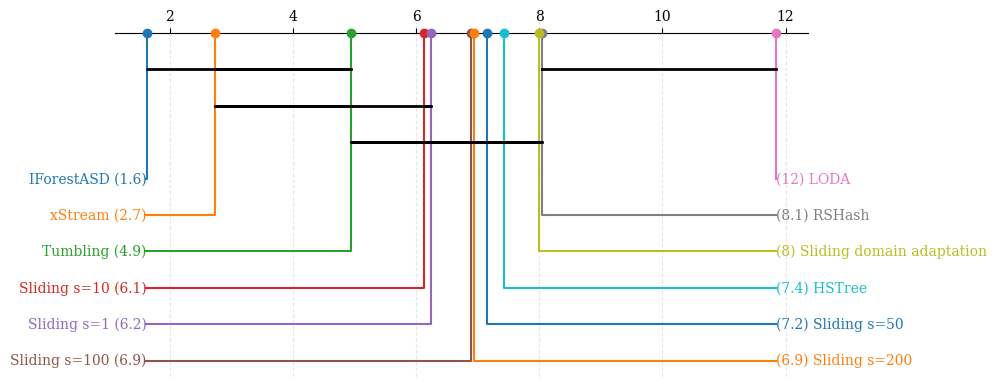

In [30]:
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare



stat, p = friedmanchisquare(*[all_auc[col] for col in all_auc.columns])
print(f"Friedman p-value : {p:.4f}")

ranks = all_auc.rank(axis=1, ascending=False).mean()

sig_matrix = sp.posthoc_nemenyi_friedman(all_auc)

plt.figure(figsize=(10, 4))
sp.critical_difference_diagram(ranks, sig_matrix)
plt.tight_layout()
plt.savefig("../results/data_/cd_diagram.eps")
plt.show()

In [31]:
dist_data = pd.concat([pivot_auc, all_auc], axis=1)


In [32]:
#pd.concat([pivot_time,df_sota_time ], axis=1).to_latex('../results/data/combine_time.tex')

In [33]:
df_sc_time = time_all.mean().to_frame(name='Time').reset_index().sort_values("index")
print(df_sc_time.columns) 
df_sc_time.columns = ["Method", "Time"]

Index(['index', 'Time'], dtype='object')


In [34]:
df_sc_time

,Method,Time
7,HSTree,621.684476
8,IForestASD,346.240565
9,LODA,657.321564
10,RSHash,171.224182
0,Sliding domain adaptation,177.961053
1,Sliding s=1,352.199123
2,Sliding s=10,31.786228
3,Sliding s=100,19.871053
4,Sliding s=200,2.136228
5,Sliding s=50,7.095702


In [35]:
df_sc_auc = all_auc.mean().to_frame(name='AUC').reset_index().sort_values("index")
print(df_sc_auc.columns) 


Index(['index', 'AUC'], dtype='object')


In [36]:
df_sc_auc.columns = ["Method", "AUC"]

In [37]:
df_sc_auc

,Method,AUC
0,HSTree,0.742599
1,IForestASD,0.951242
2,LODA,0.505902
3,RSHash,0.740075
5,Sliding domain adaptation,0.723999
6,Sliding s=1,0.753473
7,Sliding s=10,0.756869
8,Sliding s=100,0.742702
9,Sliding s=200,0.744859
10,Sliding s=50,0.748397


In [38]:
df_plot = pd.merge(df_sc_time, df_sc_auc, on='Method')



In [39]:
df_plot

,Method,Time,AUC
0,HSTree,621.684476,0.742599
1,IForestASD,346.240565,0.951242
2,LODA,657.321564,0.505902
3,RSHash,171.224182,0.740075
4,Sliding domain adaptation,177.961053,0.723999
5,Sliding s=1,352.199123,0.753473
6,Sliding s=10,31.786228,0.756869
7,Sliding s=100,19.871053,0.742702
8,Sliding s=200,2.136228,0.744859
9,Sliding s=50,7.095702,0.748397


In [40]:
df_plot

,Method,Time,AUC
0,HSTree,621.684476,0.742599
1,IForestASD,346.240565,0.951242
2,LODA,657.321564,0.505902
3,RSHash,171.224182,0.740075
4,Sliding domain adaptation,177.961053,0.723999
5,Sliding s=1,352.199123,0.753473
6,Sliding s=10,31.786228,0.756869
7,Sliding s=100,19.871053,0.742702
8,Sliding s=200,2.136228,0.744859
9,Sliding s=50,7.095702,0.748397


/tmp/ipykernel_13841/3974727408.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


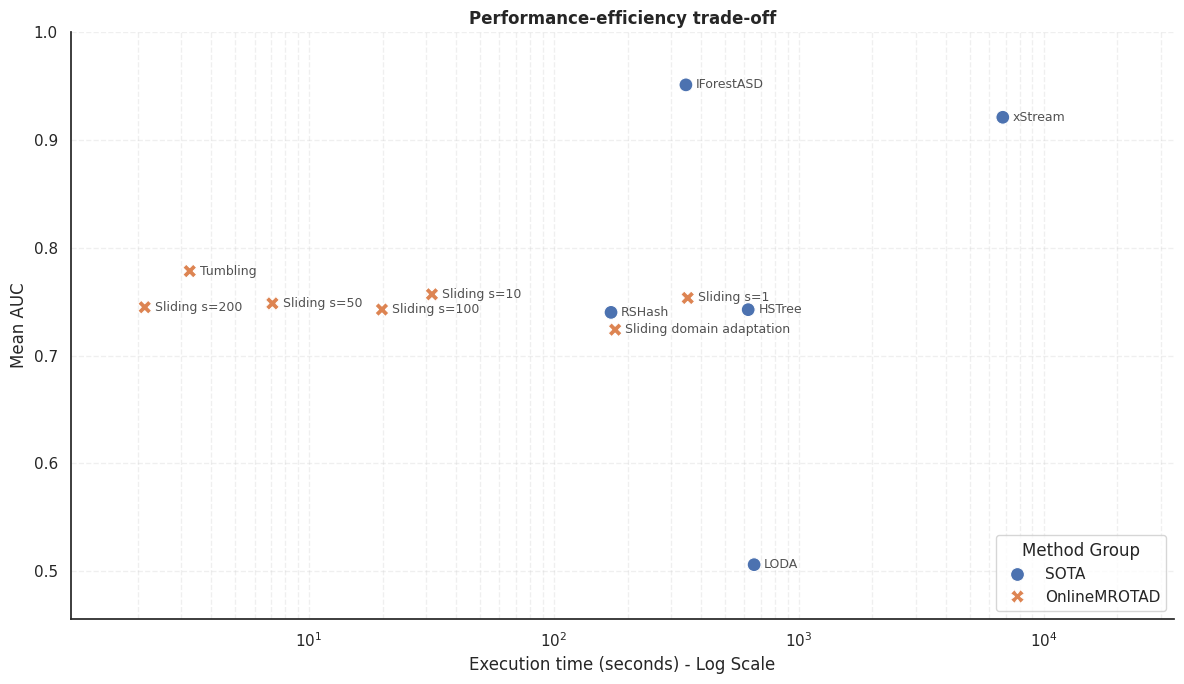

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white") 
plt.figure(figsize=(12, 7))

df_plot['Category'] = df_plot['Method'].apply(
    lambda x: 'OnlineMROTAD' if 'Sliding' in x or 'Tumbling' in x else 'SOTA'
)

plot = sns.scatterplot(
    data=df_plot, 
    x="Time",     
    y="AUC",    
    hue="Category", 
    style="Category", 
    s=100)


for i in range(df_plot.shape[0]):
    plt.text(
        x=df_plot.Time.iloc[i] * 1.1,
        y=df_plot.AUC.iloc[i], 
        s=df_plot.Method.iloc[i], 
        fontsize=9,
        alpha=0.8,
        verticalalignment='center'
    )

plt.xscale("log") 
plt.title("Performance-efficiency trade-off", fontsize=12, fontweight='bold')
plt.xlabel("Execution time (seconds) - Log Scale", fontsize=12)
plt.ylabel("Mean AUC", fontsize=12)

plt.xlim(df_plot.Time.min() * 0.5, df_plot.Time.max() * 5)
plt.ylim(df_plot.AUC.min() - 0.05, 1.0)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(title='Method Group', loc='lower right', frameon=True)
sns.despine()

plt.tight_layout()
plt.savefig("../results/data_/trade_off.eps")
plt.show()

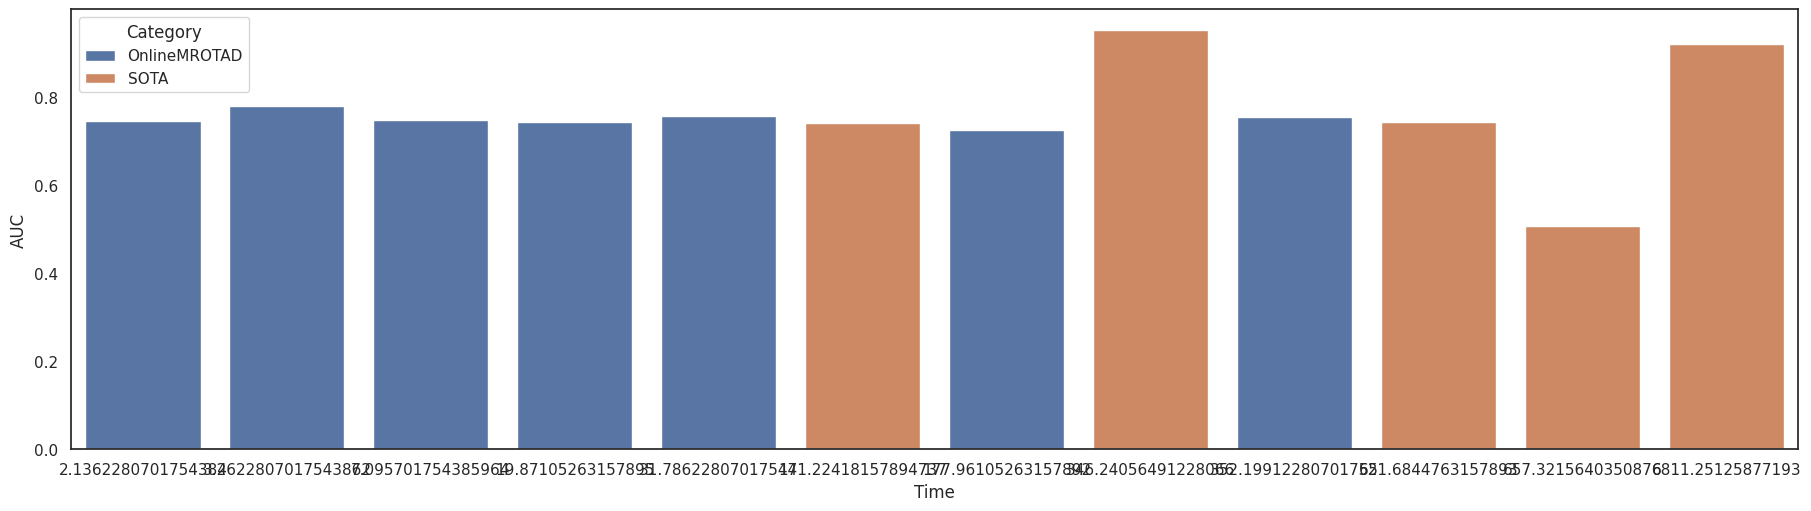

In [42]:
plt.figure(figsize=(18, 5))

sns.barplot(data=df_plot, x="Time", y="AUC", hue='Category')
plt.xticks()
plt.show()

#  4  - Best result for each method

In [43]:
import pandas as pd

def generer_latex_depuis_df(chemin_csv):
    df = pd.read_csv(chemin_csv)


    df_clean = df.sort_values(by=['AUC_Global', 'Execution_Time(s)'], 
                             ascending=[False, True]).groupby(['Dataset', 'Method']).first().reset_index()
    
    df_clean["Method"] =  df_clean['Method'].apply(change_name)
    pivot_auc = df_clean.pivot(index='Dataset', columns='Method', values='AUC_Global')
    pivot_time = df_clean.pivot(index='Dataset', columns='Method', values='Execution_Time(s)')

    algos = pivot_auc.columns.tolist()
    header_algos = " & ".join([f"\\textbf{{{a.replace('_', ' ')}}}" for a in algos])
    col_format = "l" + "c" * len(algos)

    latex_rows = []
    for dataset in pivot_auc.index:
        # Protection des underscores pour LaTeX
        ds_name = dataset.replace('_', '\\_')
        row_str = ds_name
        
        # Trouver la valeur max de la ligne pour le gras
        max_auc = pivot_auc.loc[dataset].max()
        
        for algo in algos:
            auc = pivot_auc.loc[dataset, algo]
            time = pivot_time.loc[dataset, algo]
            
            if pd.isna(auc):
                cell = "N/A"
            else:
                val_text = f"{auc:.4f} ({time:.1f}s)"
              
                if auc == max_auc:
                    cell = f"\\textbf{{{val_text}}}"
                else:
                    cell = val_text
            
            row_str += f" & {cell}"
        
        row_str += " \\\\"
        latex_rows.append(row_str)

    latex_table = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Comparaison des performances ROC et temps d'exécution}}
\\label{{tab:resultats_algos}}
\\resizebox{{\\textwidth}}{{!}}{{% Force le tableau à tenir sur la largeur de la page
\\begin{{tabular}}{{{col_format}}}
\\toprule
\\textbf{{Dataset}} & {header_algos} \\\\
\\midrule
"""
    latex_table += "\n".join(latex_rows)
    latex_table += """
\\bottomrule
\\end{tabular}
}
\\end{table}
"""
    return latex_table, pivot_auc


In [44]:

code_latex, pivot_auc = generer_latex_depuis_df('../results/df_total.csv')
#print(code_latex)

In [45]:
pivot_auc

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,0.5065,0.9110,0.9206,0.8467,0.9093,0.8757,0.9185
Ionosphere_shake_gradual,0.7873,0.8006,0.7978,0.7981,0.7954,0.7994,0.8007
Ionosphere_shake_sudden_2,0.8227,0.8228,0.8226,0.8231,0.8184,0.8224,0.8221
S1,0.6733,0.7124,0.8053,0.6768,0.6624,0.7939,0.8063
S2,0.7659,0.7154,0.7151,0.7206,0.8158,0.7192,0.7659
WOBC_shake_gradual_2,0.6972,0.6972,0.6971,0.6973,0.6983,0.6972,0.7006
WOBC_shake_sudden,0.7297,0.7297,0.7297,0.7406,0.7535,0.7303,0.7303
dermatology_shake_gradual,0.7037,0.7699,0.7572,0.7626,0.7626,0.7613,0.7649
dermatology_shake_sudden_2,0.7941,0.7994,0.8292,0.8303,0.8291,0.8061,0.7834


In [46]:
best_pivot_auc = pivot_auc[['Sliding domain adaptation', 'Sliding s=200', 'Tumbling']]

In [47]:
best_pivot_auc

Method,Sliding domain adaptation,Sliding s=200,Tumbling
Dataset,,,
COIL20_mix_sudden,0.5065,0.9093,0.9185
Ionosphere_shake_gradual,0.7873,0.7954,0.8007
Ionosphere_shake_sudden_2,0.8227,0.8184,0.8221
S1,0.6733,0.6624,0.8063
S2,0.7659,0.8158,0.7659
WOBC_shake_gradual_2,0.6972,0.6983,0.7006
WOBC_shake_sudden,0.7297,0.7535,0.7303
dermatology_shake_gradual,0.7037,0.7626,0.7649
dermatology_shake_sudden_2,0.7941,0.8291,0.7834


/tmp/ipykernel_13841/1193620463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot_auc.columns, y=pivot_auc.mean(), palette="viridis")


Text(0, 0.5, 'AUC Moyen')

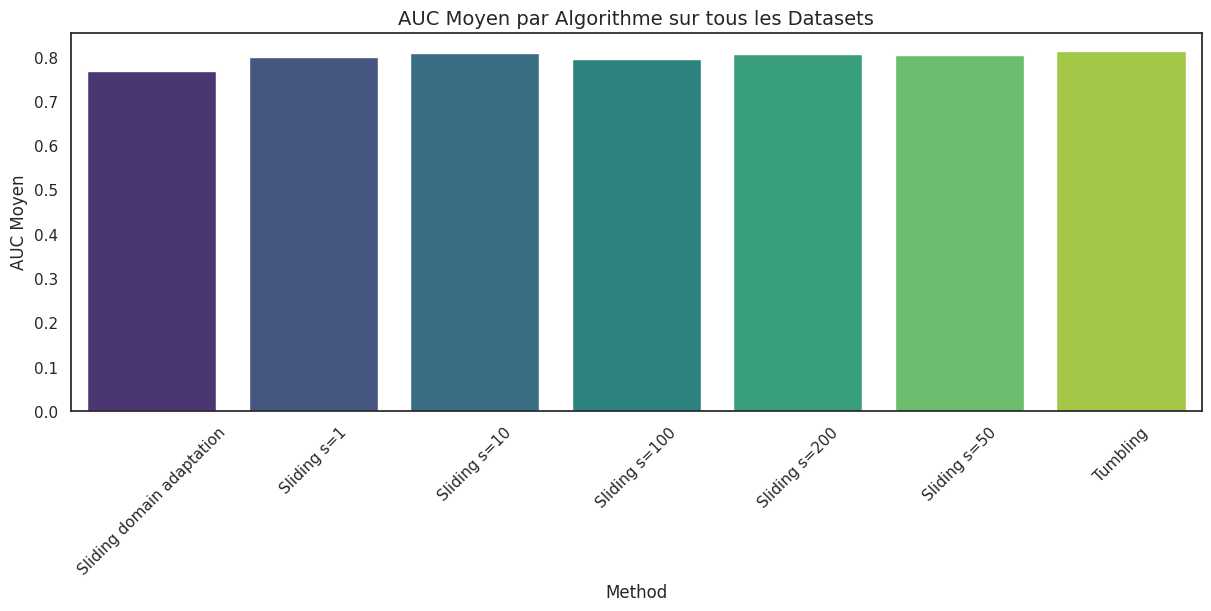

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(x=pivot_auc.columns, y=pivot_auc.mean(), palette="viridis")
plt.xticks(rotation=45)
plt.title("AUC Moyen par Algorithme sur tous les Datasets", fontsize=14)
plt.ylabel("AUC Moyen")

In [49]:
sota_auc = pd.read_csv("../results/pivot_roc_sota.csv")

In [50]:
combined_means = pd.concat([best_pivot_auc.mean(), sota_auc.mean()], axis=0, keys=['OnlineMROTAD', 'SOTA'])


In [51]:
combined_means

OnlineMROTAD  Sliding domain adaptation    0.768505
              Sliding s=200                0.806132
              Tumbling                     0.814158
SOTA          HSTree                       0.750121
              IForestASD                   0.958553
              LODA                         0.511879
              RSHash                       0.742458
              xStream                      0.935589
dtype: float64

/tmp/ipykernel_13841/1672379872.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


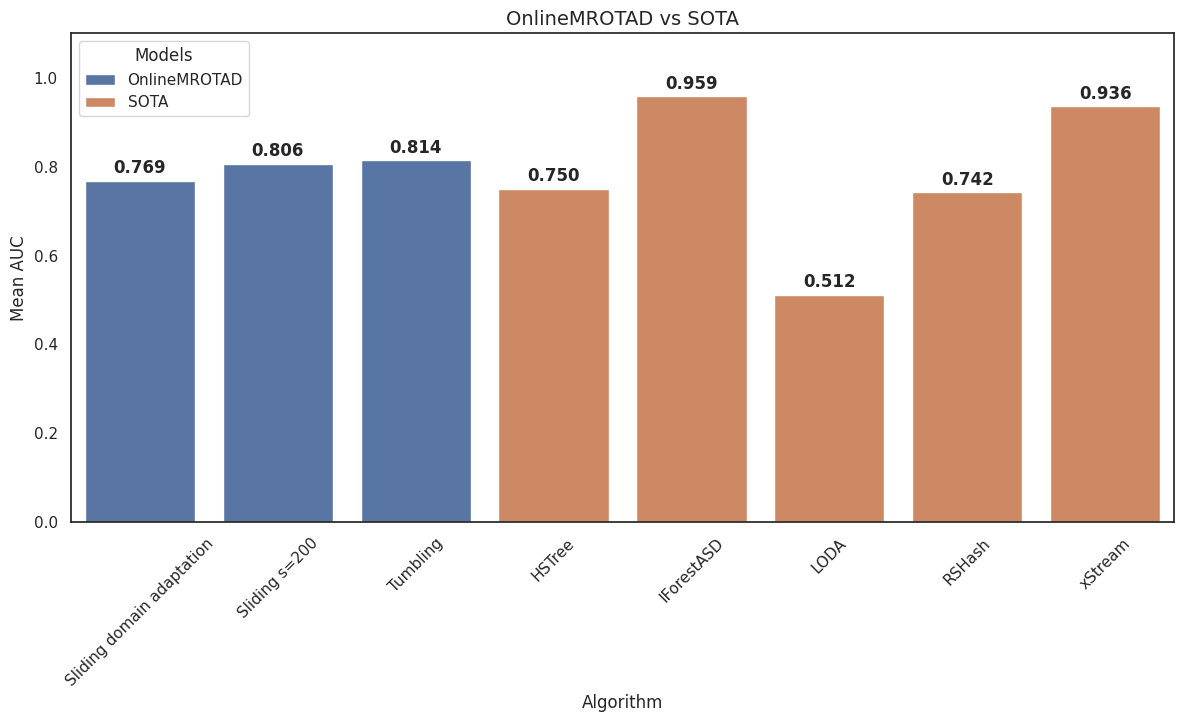

In [52]:


plt.figure(figsize=(12, 6))

plot_df = combined_means.reset_index()
plot_df.columns = ['Category', 'Algorithm', 'Mean_AUC']

ax = sns.barplot(data=plot_df, x='Algorithm', y='Mean_AUC', hue='Category', dodge=False)

plt.title("OnlineMROTAD vs SOTA", fontsize=14)
plt.ylabel("Mean AUC")
plt.ylim(0, 1.1)
plt.legend(title="Models")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.xticks(rotation=45)

plt.savefig("../results/data_/best_mean_result.eps", format='eps', bbox_inches='tight')
#plt.savefig("results/mean_auc_comparison.png", bbox_inches='tight')  # PNG pour vérifier visuellement

plt.show()

In [53]:
#!pip install scikit-posthocs

In [54]:
sota_auc.index =  pivot_auc.index

In [55]:
cbm = pd.concat([best_pivot_auc, sota_auc], axis=1)


In [56]:
cbm.columns = ['OnMROT-S domain adaptation', 'OnMROT-Sliding', 'OnMROT-Tumbling', 'HSTree','IForestASD', 'LODA', 'RSHash', 'xStream']

Friedman p-value : 0.0000


/tmp/ipykernel_13841/743191865.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


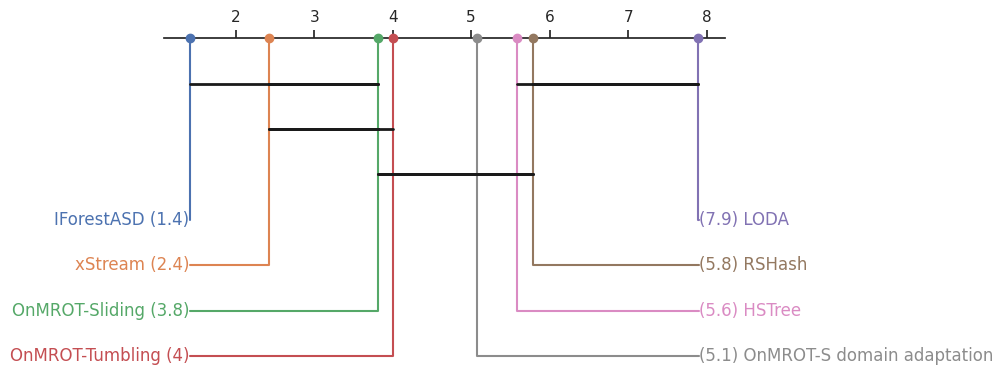

In [57]:
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare



stat, p = friedmanchisquare(*[cbm[col] for col in cbm.columns])
print(f"Friedman p-value : {p:.4f}")

ranks = cbm.rank(axis=1, ascending=False).mean()

sig_matrix = sp.posthoc_nemenyi_friedman(cbm)

plt.figure(figsize=(10, 4))
sp.critical_difference_diagram(ranks, sig_matrix)
plt.tight_layout()
plt.savefig("../results/data_/cd_diagram2.eps", dpi=150, bbox_inches="tight")
plt.show()

In [58]:

def generate_latex_summary(csv_path):
    df = pd.read_csv(csv_path)

    idx_max_global = df.sort_values(
        by=['AUC_Global', 'Execution_Time(s)'], 
        ascending=[False, True]
    ).groupby('Dataset')['AUC_Global'].idxmax()
    
    best_configs = df.loc[idx_max_global].copy()

    def format_params(row):
        d = int(row['Num_Drifts'])
        w = int(row['Windows size'])
        t = row['Anomaly threshold']
        o = int(row['offline_size'])
        return f"D:{d}, W:{w}, T:{t}, O:{o}"

    best_configs['Config_Str'] = best_configs.apply(format_params, axis=1)
    params_map = best_configs.set_index('Dataset')['Config_Str'].to_dict()

    df_grouped = df.sort_values(
        by=['AUC_Global', 'Execution_Time(s)'], 
        ascending=[False, True]
    ).groupby(['Dataset', 'Method']).first().reset_index()
    
    pivot_auc = df_grouped.pivot(index='Dataset', columns='Method', values='AUC_Global')
    pivot_time = df_grouped.pivot(index='Dataset', columns='Method', values='Execution_Time(s)')

    methods = pivot_auc.columns.tolist()
    latex_rows = []

    for dataset in pivot_auc.index:
        # Protection des caractères spéciaux LaTeX
        ds_escaped = dataset.replace('_', '\\_')
        config_escaped = params_map.get(dataset, "").replace('_', '\\_')
        
        row_str = f"{ds_escaped} & {config_escaped}"
        
        row_auc_values = pivot_auc.loc[dataset]
        max_auc_row = row_auc_values.max()
        
        for method in methods:
            auc = pivot_auc.loc[dataset, method]
            time = pivot_time.loc[dataset, method]
            
            if pd.isna(auc):
                cell = "N/A"
            else:
                val_text = f"{auc:.4f} ({time:.1f}s)"
                # Mise en gras si c'est le max de la ligne
                if auc == max_auc_row:
                    cell = f"\\textbf{{{val_text}}}"
                else:
                    cell = val_text
            row_str += f" & {cell}"
        
        row_str += " \\\\"
        latex_rows.append(row_str)

    header_methods = " & ".join([f"\\textbf{{{m.replace('_', ' ')}}}" for m in methods])
    col_format = "l" + "c" * (len(methods) + 1)

    latex_code = f"""
\\begin{{sidewaystable}}[htbp]
\\centering
\\caption{{Performances ROC, Temps et Paramètres Optimaux (D:Drifts, W:Window, T:Threshold, O:Offline)}}
\\label{{tab:results_params}}
\\resizebox{{\\textheight}}{{!}}{{%
\\begin{{tabular}}{{{col_format}}}
\\toprule
\\textbf{{Dataset}} & \\textbf{{Best Config}} & {header_methods} \\\\
\\midrule
"""
    latex_code += "\n".join(latex_rows)
    latex_code += """
\\bottomrule
\\end{tabular}
}
\\end{sidewaystable}
"""
    return latex_code, df_grouped


In [59]:

final_latex, df_grouped = generate_latex_summary('../results/df_total.csv')
        

In [60]:

df_best = (
    df.sort_values(by=['AUC_Global', 'Execution_Time(s)'], ascending=[False, True])
      .groupby(['Dataset', 'Method'])
      .first()
      .reset_index()
)

In [61]:
df_best = df_best[['Dataset','Method','AUC_Global','Execution_Time(s)' ]]

In [62]:
df_best.head()

,Dataset,Method,AUC_Global,Execution_Time(s)
0,COIL20_mix_sudden,Sliding domain adaptation,0.5065,956.10
1,COIL20_mix_sudden,Sliding s=1,0.9110,1712.08
2,COIL20_mix_sudden,Sliding s=10,0.9206,192.29
3,COIL20_mix_sudden,Sliding s=100,0.8467,23.61
4,COIL20_mix_sudden,Sliding s=200,0.9093,19.55


In [63]:
df_best.shape

(133, 4)

In [64]:
time_sota = pd.read_csv("../results/data_/roc_time_sota.csv")   

In [65]:
time_sota.Algorithm.unique()

array(['HSTree', 'IForestASD', 'LODA', 'RSHash', 'xStream'], dtype=object)

In [66]:
time_sota.columns = list(df_best.columns)

In [67]:
combine_time_auc = pd.concat([df_best, time_sota])

In [68]:
combine_time_auc.head()

,Dataset,Method,AUC_Global,Execution_Time(s)
0,COIL20_mix_sudden,Sliding domain adaptation,0.5065,956.10
1,COIL20_mix_sudden,Sliding s=1,0.9110,1712.08
2,COIL20_mix_sudden,Sliding s=10,0.9206,192.29
3,COIL20_mix_sudden,Sliding s=100,0.8467,23.61
4,COIL20_mix_sudden,Sliding s=200,0.9093,19.55


In [69]:
df_filtered = combine_time_auc[~combine_time_auc["Method"].isin([
    "Sliding s=1", "Sliding s=10", "Sliding s=100",'Sliding s=5', 'Sliding s=50'
])]

In [70]:
df_filtered

,Dataset,Method,AUC_Global,Execution_Time(s)
0,COIL20_mix_sudden,Sliding domain adaptation,0.5065,956.1000
4,COIL20_mix_sudden,Sliding s=200,0.9093,19.5500
6,COIL20_mix_sudden,Tumbling,0.9185,20.0100
7,Ionosphere_shake_gradual,Sliding domain adaptation,0.7873,119.6200
11,Ionosphere_shake_gradual,Sliding s=200,0.7954,1.2900
...,...,...,...,...
90,wine_shake_sudden_2,HSTree,0.7519,2348.7855
91,wine_shake_sudden_2,IForestASD,0.9835,149.4110
92,wine_shake_sudden_2,LODA,0.5000,187.2652
93,wine_shake_sudden_2,RSHash,0.7435,300.1258


In [71]:
df_filtered['Method'] = np.where(df_filtered.Method == 'Sliding s=200',"Sliding",  df_filtered['Method'] )


/tmp/ipykernel_13841/829431386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Method'] = np.where(df_filtered.Method == 'Sliding s=200',"Sliding",  df_filtered['Method'] )


In [72]:
last = df_filtered.groupby("Method").mean(numeric_only=True).reset_index()

In [73]:
df_filtered

,Dataset,Method,AUC_Global,Execution_Time(s)
0,COIL20_mix_sudden,Sliding domain adaptation,0.5065,956.1000
4,COIL20_mix_sudden,Sliding,0.9093,19.5500
6,COIL20_mix_sudden,Tumbling,0.9185,20.0100
7,Ionosphere_shake_gradual,Sliding domain adaptation,0.7873,119.6200
11,Ionosphere_shake_gradual,Sliding,0.7954,1.2900
...,...,...,...,...
90,wine_shake_sudden_2,HSTree,0.7519,2348.7855
91,wine_shake_sudden_2,IForestASD,0.9835,149.4110
92,wine_shake_sudden_2,LODA,0.5000,187.2652
93,wine_shake_sudden_2,RSHash,0.7435,300.1258


In [74]:
last

,Method,AUC_Global,Execution_Time(s)
0,HSTree,0.750121,689.472100
1,IForestASD,0.958553,145.686805
2,LODA,0.511879,187.030026
3,RSHash,0.742458,180.087621
4,Sliding,0.806132,2.429474
5,Sliding domain adaptation,0.768505,443.530000
6,Tumbling,0.814158,3.264737
7,xStream,0.935589,3399.988284


In [75]:
last['Method'] = np.where(last.Method == 'Sliding s=200',"Sliding",  last['Method'] )


In [76]:
last

,Method,AUC_Global,Execution_Time(s)
0,HSTree,0.750121,689.472100
1,IForestASD,0.958553,145.686805
2,LODA,0.511879,187.030026
3,RSHash,0.742458,180.087621
4,Sliding,0.806132,2.429474
5,Sliding domain adaptation,0.768505,443.530000
6,Tumbling,0.814158,3.264737
7,xStream,0.935589,3399.988284


In [77]:
combine_time_auc.Method.unique()

array(['Sliding domain adaptation', 'Sliding s=1', 'Sliding s=10',
       'Sliding s=100', 'Sliding s=200', 'Sliding s=50', 'Tumbling',
       'HSTree', 'IForestASD', 'LODA', 'RSHash', 'xStream'], dtype=object)

In [78]:
#online.to_csv('../results/onlinemrottime.csv', index=False)

In [79]:
#!pip install adjustText

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


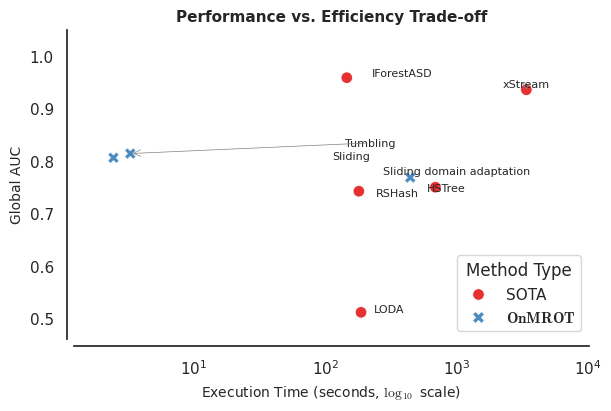

In [84]:
from adjustText import adjust_text


last['Category'] = last['Method'].apply(
    lambda x: r'$\mathbf{OnMROT}$' if ('Sliding' in x or 'Tumbling' in x) else 'SOTA'
)

fig, ax = plt.subplots(figsize=(6, 4))


scatter = sns.scatterplot(
    data=last, 
    x="Execution_Time(s)",     
    y="AUC_Global",    
    hue="Category", 
    style="Category", 
    s=70,             
    alpha=0.9,
    edgecolor='w',    
    palette="Set1",   
    ax=ax
)

texts = []
for _, row in last.iterrows():
    # Nettoyage du nom pour éviter les erreurs de rendu
    label = row['Method'].replace('_', ' ')
    
    texts.append(ax.text(
        row['Execution_Time(s)'], 
        row['AUC_Global'],
        label,
        fontsize=8,
        fontweight='medium'
    ))

# L'algorithme ajuste les positions pour éviter les collisions
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), # Ajoute des flèches si besoin
    expand_points=(1.5, 1.5),
    ax=ax
)

ax.set_xscale("log")
ax.set_title(r"Performance vs. Efficiency Trade-off", fontsize=11, fontweight='bold')
ax.set_xlabel(r"Execution Time (seconds, $\log_{10}$ scale)", fontsize=10)
ax.set_ylabel(r"Global AUC", fontsize=10)

ax.set_xlim(last["Execution_Time(s)"].min() * 0.5,
            last["Execution_Time(s)"].max() * 3.0)
ax.set_ylim(last["AUC_Global"].min() - 0.05, 1.05)

# 6. Légende et finition
ax.legend(title=r'Method Type', loc='lower right', frameon=True, edgecolor='0.8')
sns.despine(ax=ax, offset=5)

plt.savefig('../results/data_/trade_off_final.eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


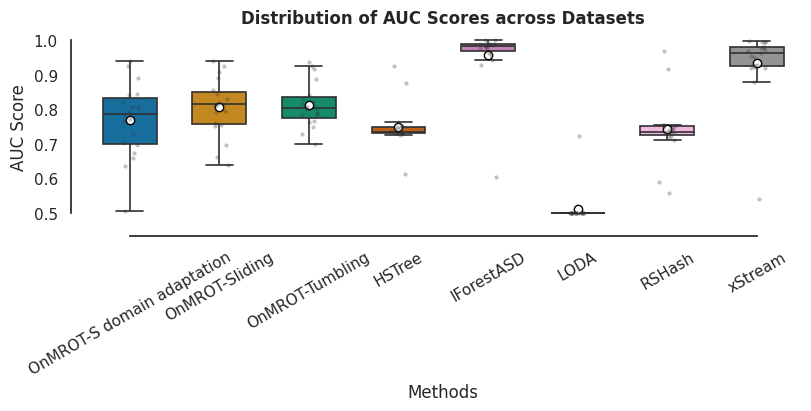

In [81]:


fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=cbm, 
    palette="colorblind", 
    showmeans=True, 
    width=0.6,
    linewidth=1.2,
    fliersize=0,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": 6},
    ax=ax
)

sns.stripplot(data=cbm, color=".2", alpha=0.3, size=3, jitter=True, ax=ax)

ax.set_title(r"Distribution of AUC Scores across Datasets", fontsize=12, fontweight='bold')
ax.set_ylabel("AUC Score")
ax.set_xlabel("Methods")

sns.despine(trim=True, offset=10)
plt.xticks(rotation=30)
plt.savefig("../results/data_/boxplot.eps")
plt.show()

In [82]:
df_filtered

,Dataset,Method,AUC_Global,Execution_Time(s)
0,COIL20_mix_sudden,Sliding domain adaptation,0.5065,956.1000
4,COIL20_mix_sudden,Sliding,0.9093,19.5500
6,COIL20_mix_sudden,Tumbling,0.9185,20.0100
7,Ionosphere_shake_gradual,Sliding domain adaptation,0.7873,119.6200
11,Ionosphere_shake_gradual,Sliding,0.7954,1.2900
...,...,...,...,...
90,wine_shake_sudden_2,HSTree,0.7519,2348.7855
91,wine_shake_sudden_2,IForestASD,0.9835,149.4110
92,wine_shake_sudden_2,LODA,0.5000,187.2652
93,wine_shake_sudden_2,RSHash,0.7435,300.1258
